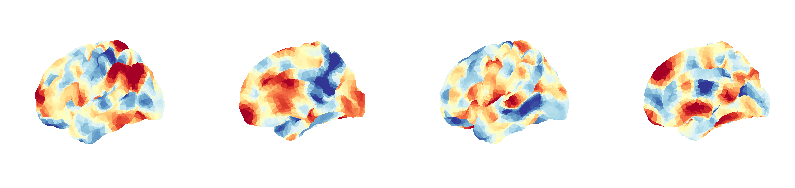

In [1]:
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from neuromaps import nulls, stats
from neuromaps.datasets import fetch_atlas
from neuromaps.points import get_surface_distance
from nilearn import plotting
from nilearn import surface as nl_surface

from compare_brain_maps import surface

# fetch both hemispheres
fsaverage = fetch_atlas(atlas="fsaverage", density="3k")
surface_mesh_L = nl_surface.load_surf_mesh(fsaverage["pial"].L)
surface_mesh_R = nl_surface.load_surf_mesh(fsaverage["pial"].R)
medial_wall_L = nl_surface.load_surf_data(fsaverage["medial"].L)
medial_wall_R = nl_surface.load_surf_data(fsaverage["medial"].R)

# initialize parameters
rng = np.random.default_rng(seed=0)
n_vertices_L = surface_mesh_L.coordinates.shape[0]
n_vertices_R = surface_mesh_R.coordinates.shape[0]

# generate X iid N
X_L = rng.multivariate_normal([0, 0], [[1, 0], [0, 1]], size=n_vertices_L)
X_R = rng.multivariate_normal([0, 0], [[1, 0], [0, 1]], size=n_vertices_R)
X_L = X_L - X_L.mean(axis=0)
X_R = X_R - X_R.mean(axis=0)

# smooth both hemispheres
X_sm_L = surface.smooth_surface_data(surface_mesh_L, X_L, iterations=8, match="dist").astype(np.float32)
X_sm_R = surface.smooth_surface_data(surface_mesh_R, X_R, iterations=8, match="dist").astype(np.float32)

# save first maps to GIFTI files (to work with neuromaps)
gii_L = nib.gifti.GiftiImage(darrays=[nib.gifti.GiftiDataArray(X_sm_L[:, 0])])
gii_R = nib.gifti.GiftiImage(darrays=[nib.gifti.GiftiDataArray(X_sm_R[:, 0])])
nib.save(gii_L, "X1_sm_left.func.gii")
nib.save(gii_R, "X1_sm_right.func.gii")

gii_L = nib.gifti.GiftiImage(darrays=[nib.gifti.GiftiDataArray(X_sm_L[:, 1])])
gii_R = nib.gifti.GiftiImage(darrays=[nib.gifti.GiftiDataArray(X_sm_R[:, 1])])
nib.save(gii_L, "X2_sm_left.func.gii")
nib.save(gii_R, "X2_sm_right.func.gii")

# plot surfaces
fig, axs = plt.subplots(ncols=4, figsize=(10, 4), subplot_kw=dict(projection="3d"))
plot_kwargs = dict(cmap="RdYlBu", vmin=-2, vmax=2)
_ = plotting.plot_surf(surface_mesh_L, X_sm_L[:, 0], axes=axs[0], **plot_kwargs)
_ = plotting.plot_surf(surface_mesh_R, X_sm_R[:, 0], axes=axs[1], **plot_kwargs)
_ = plotting.plot_surf(surface_mesh_L, X_sm_L[:, 1], axes=axs[2], **plot_kwargs)
_ = plotting.plot_surf(surface_mesh_R, X_sm_R[:, 1], axes=axs[3], **plot_kwargs)

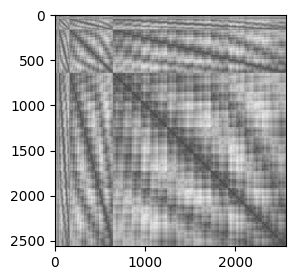

In [2]:
# calculate vertex-vertex distances
D = get_surface_distance(fsaverage["pial"].L)

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(D, cmap="binary_r", alpha=0.75)

| Method           | Null Model        | Description                                                        |
|------------------|--------------------------|--------------------------------------------------------------------|
|`naive`           | Permutation | Permutes vertex locations
| `alexander_bloch`  | Permutation      | Rotates spherical surface, reassigns values by nearest vertex      |
| `burt2018`         | Parametric | Spatial autoregressive (lag) model                                 |
| `burt2020`         | Parametric | Variogram matching: smooths/rescales permuted data to match autocorrelation |
| `moran`            | Parametric | Moran spectral randomization using spatial eigenvectors            |

/Users/griegner/git-repositories/compare-brain-maps/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


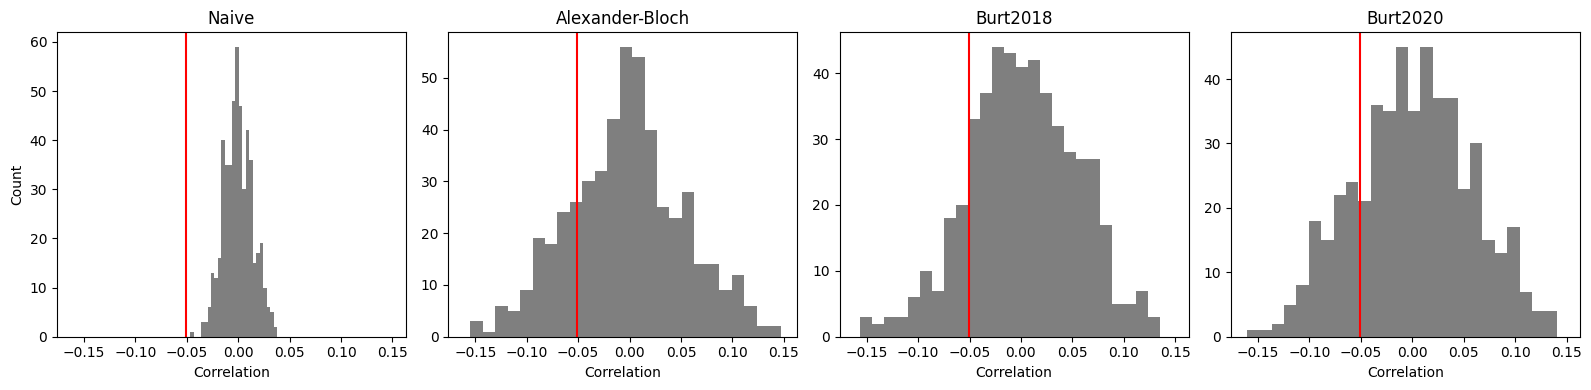

In [ ]:
# !! 30min runtime !! #
results = []

# naive
seed = 123
n_perm = 500
rng = np.random.default_rng(seed)
naive = np.column_stack([rng.permutation(n_vertices_L + n_vertices_R) for _ in range(n_perm)])
corr_naive, _, nulls_naive = stats.compare_images(
    src=("X1_sm_left.func.gii", "X1_sm_right.func.gii"),
    trg=("X2_sm_left.func.gii", "X2_sm_right.func.gii"),
    metric="pearsonr",
    nulls=naive,
    return_nulls=True,
)
results.append(("Naive", nulls_naive, corr_naive))

# alexander bloch
alexander_bloch = nulls.alexander_bloch(
    ("X1_sm_left.func.gii", "X1_sm_right.func.gii"), atlas="fsaverage", density="3k", n_perm=n_perm, seed=seed
)
corr_ab, _, nulls_ab = stats.compare_images(
    src=("X1_sm_left.func.gii", "X1_sm_right.func.gii"),
    trg=("X2_sm_left.func.gii", "X2_sm_right.func.gii"),
    metric="pearsonr",
    nulls=alexander_bloch,
    return_nulls=True,
)
results.append(("Alexander-Bloch", nulls_ab, corr_ab))

# burt 2018
burt2018 = nulls.burt2018(
    ("X1_sm_left.func.gii", "X1_sm_right.func.gii"),
    atlas="fsaverage",
    density="3k",
    n_perm=n_perm,
    seed=seed,
    n_proc=-2,
)
corr_burt18, _, nulls_burt18 = stats.compare_images(
    src=("X1_sm_left.func.gii", "X1_sm_right.func.gii"),
    trg=("X2_sm_left.func.gii", "X2_sm_right.func.gii"),
    metric="pearsonr",
    nulls=burt2018,
    return_nulls=True,
)
results.append(("Burt2018", nulls_burt18, corr_burt18))

# burt 2020
burt2020 = nulls.burt2020(
    ("X1_sm_left.func.gii", "X1_sm_right.func.gii"),
    atlas="fsaverage",
    density="3k",
    n_perm=n_perm,
    seed=seed,
    n_proc=-2,
)
corr_burt20, _, nulls_burt20 = stats.compare_images(
    src=("X1_sm_left.func.gii", "X1_sm_right.func.gii"),
    trg=("X2_sm_left.func.gii", "X2_sm_right.func.gii"),
    metric="pearsonr",
    nulls=burt2020,
    return_nulls=True,
)
results.append(("Burt2020", nulls_burt20, corr_burt20))

# plot results
fig, axs = plt.subplots(nrows=1, ncols=len(results), figsize=(16, 4), sharex=True)
for ax, (title, nulls_, corr_) in zip(axs, results):
    ax.hist(nulls_, bins=25, color="k", alpha=0.5)
    ax.axvline(corr_, c="r")
    ax.set_title(title)
    ax.set_xlabel("Correlation")
axs[0].set_ylabel("Count")
plt.tight_layout()
plt.show()